## About Dataset

#### Context
"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." 

- Content
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

##### The data set includes information about:

Customers who left within the last month 
 - the column is called Churn
 - Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
 - Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
 - Demographic info about customers – gender, age range, and if they have partners and dependents

### Exploration and Data Loading

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)

In [3]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

df.shape

(7043, 21)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
column_descriptions = {

    'customerID': 'Customer Identifier',
    
    # demographic variables
    'gender': 'Client Gender (Male/Female)',
    'SeniorCitizen': '¿Senior Citizen? (0=No, 1= Yes)',
    'Partner': '¿Have Partner? (Yes/No)',
    'Dependents': '¿Have Dependents/sons? (Yes/No)',
    
    # acoount vbriables
    'tenure': 'months as client (seniority)',
    
    # phone services
    'PhoneService': '¿Does have phone? (Yes/No)',
    'MultipleLines': '¿Does have multiple lines? (Yes/No/No phone service)',
    
    # Internet Services
    'InternetService': 'Internet Type monthlycharges(DSL/Fiber optic/No)',
    'OnlineSecurity': '¿Does It have online security? (Yes/No/No internet service)',
    'OnlineBackup': '¿Does have online backup? (Yes/No/No internet service)',
    'DeviceProtection': '¿Does have device protection? (Yes/No/No internet service)',
    'TechSupport': '¿Does have technically support? (Yes/No/No internet service)',
    'StreamingTV': '¿Does have TV streaming? (Yes/No/No internet service)',
    'StreamingMovies': '¿Does have streaming movies? (Yes/No/No internet service)',
    
    # Contract and billing
    'Contract': 'Contract type (Month-to-month/One year/Two year)',
    'PaperlessBilling': '¿Electronic Invoicing? (Yes/No)',
    'PaymentMethod': 'Pay Method',
    

    'MonthlyCharges': 'Monthly fee in dollars',
    'TotalCharges': 'Total accumulated charges in dollars',
    
    # TARGET 
    'Churn': '¿Is the customer leave? (Yes/No) - Target Feature'
}

print("\n" + "=" * 60)
print("Variables Dictionary")
print("=" * 60 + "\n")

for col, desc in column_descriptions.items():
    print(f"• {col:18s} → {desc}")


Variables Dictionary

• customerID         → Customer Identifier
• gender             → Client Gender (Male/Female)
• SeniorCitizen      → ¿Senior Citizen? (0=No, 1= Yes)
• Partner            → ¿Have Partner? (Yes/No)
• Dependents         → ¿Have Dependents/sons? (Yes/No)
• tenure             → months as client (seniority)
• PhoneService       → ¿Does have phone? (Yes/No)
• MultipleLines      → ¿Does have multiple lines? (Yes/No/No phone service)
• InternetService    → Internet Type monthlycharges(DSL/Fiber optic/No)
• OnlineSecurity     → ¿Does It have online security? (Yes/No/No internet service)
• OnlineBackup       → ¿Does have online backup? (Yes/No/No internet service)
• DeviceProtection   → ¿Does have device protection? (Yes/No/No internet service)
• TechSupport        → ¿Does have technically support? (Yes/No/No internet service)
• StreamingTV        → ¿Does have TV streaming? (Yes/No/No internet service)
• StreamingMovies    → ¿Does have streaming movies? (Yes/No/No internet 

In [7]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [8]:
df['SeniorCitizen'].unique()

array([0, 1], dtype=int64)

 - Based on  the describe (and explorartion) we can see that most categorical variables have between 2, 3 or 4 categories
 - So for those that only have 2 (binary) lets just replace by 0 and 1
 - For those that have 3 or 4 we can do OHE (One Hot Encoding)

#### Binary Encoding

In [9]:
binary_cols = ["gender","Partner","Dependents","PhoneService","PaperlessBilling","Churn"]


#before process encoding
print(f"Before:")
for col in binary_cols:
    print(f"{col} unique values: {df[col].unique()}")

df[binary_cols] = df[binary_cols].replace({
    'Yes':1,'No':0,'Male':1,'Female':0
})


#After
print(f"\nAfter:")
for col in binary_cols:
    print(f"{col} unique values: {df[col].unique()}")

Before:
gender unique values: ['Female' 'Male']
Partner unique values: ['Yes' 'No']
Dependents unique values: ['No' 'Yes']
PhoneService unique values: ['No' 'Yes']
PaperlessBilling unique values: ['Yes' 'No']
Churn unique values: ['No' 'Yes']

After:
gender unique values: [0 1]
Partner unique values: [1 0]
Dependents unique values: [0 1]
PhoneService unique values: [0 1]
PaperlessBilling unique values: [1 0]
Churn unique values: [0 1]


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   int64  


In [11]:
df.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0


#### One Hot Encoding

In [12]:
# Categorical columns with > 2 unique values
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

df = pd.get_dummies(df,columns=multi_cat_cols,drop_first=True)

In [13]:
df.shape

(7043, 32)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   gender                                 7043 non-null   int64  
 2   SeniorCitizen                          7043 non-null   int64  
 3   Partner                                7043 non-null   int64  
 4   Dependents                             7043 non-null   int64  
 5   tenure                                 7043 non-null   int64  
 6   PhoneService                           7043 non-null   int64  
 7   PaperlessBilling                       7043 non-null   int64  
 8   MonthlyCharges                         7043 non-null   float64
 9   TotalCharges                           7043 non-null   object 
 10  Churn                                  7043 non-null   int64  
 11  Mult

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [16]:
for col in df.columns:
    print(f" {col} Null values: {df[col].isna().sum()}")

 customerID Null values: 0
 gender Null values: 0
 SeniorCitizen Null values: 0
 Partner Null values: 0
 Dependents Null values: 0
 tenure Null values: 0
 PhoneService Null values: 0
 PaperlessBilling Null values: 0
 MonthlyCharges Null values: 0
 TotalCharges Null values: 0
 Churn Null values: 0
 MultipleLines_No phone service Null values: 0
 MultipleLines_Yes Null values: 0
 InternetService_Fiber optic Null values: 0
 InternetService_No Null values: 0
 OnlineSecurity_No internet service Null values: 0
 OnlineSecurity_Yes Null values: 0
 OnlineBackup_No internet service Null values: 0
 OnlineBackup_Yes Null values: 0
 DeviceProtection_No internet service Null values: 0
 DeviceProtection_Yes Null values: 0
 TechSupport_No internet service Null values: 0
 TechSupport_Yes Null values: 0
 StreamingTV_No internet service Null values: 0
 StreamingTV_Yes Null values: 0
 StreamingMovies_No internet service Null values: 0
 StreamingMovies_Yes Null values: 0
 Contract_One year Null values: 0
 C

In [17]:

for col in df.columns:
    print(f"{col}: {(df[col] == ' ').sum()}")

customerID: 0
gender: 0
SeniorCitizen: 0
Partner: 0
Dependents: 0
tenure: 0
PhoneService: 0
PaperlessBilling: 0
MonthlyCharges: 0
TotalCharges: 11
Churn: 0
MultipleLines_No phone service: 0
MultipleLines_Yes: 0
InternetService_Fiber optic: 0
InternetService_No: 0
OnlineSecurity_No internet service: 0
OnlineSecurity_Yes: 0
OnlineBackup_No internet service: 0
OnlineBackup_Yes: 0
DeviceProtection_No internet service: 0
DeviceProtection_Yes: 0
TechSupport_No internet service: 0
TechSupport_Yes: 0
StreamingTV_No internet service: 0
StreamingTV_Yes: 0
StreamingMovies_No internet service: 0
StreamingMovies_Yes: 0
Contract_One year: 0
Contract_Two year: 0
PaymentMethod_Credit card (automatic): 0
PaymentMethod_Electronic check: 0
PaymentMethod_Mailed check: 0


##### Observation
- TotalCharges have null values and appear like object we must convert TotalCharges feature in numeric values

In [18]:
total_charges_numeric = pd.to_numeric(df['TotalCharges'],errors='coerce')
problematic_rows = total_charges_numeric.isna().sum()

print(f"Problem Values: {problematic_rows}")
print(f"Total Percentage: {100*problematic_rows/ len(df):.2f}%")


Problem Values: 11
Total Percentage: 0.16%


In [19]:
(total_charges_numeric == np.nan).sum()

0

In [20]:
(df['TotalCharges'] == np.nan).sum()

0

### Cleaning

In [21]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [22]:
df = df.drop(labels=['customerID'],axis=1)

In [23]:
bools_cols = df.select_dtypes(include='bool').columns
df[bools_cols] = df[bools_cols].astype(int) # converts True/False to 1/0 for all boolean cols

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int32  
 11  Mult

### Correlation Heatmap

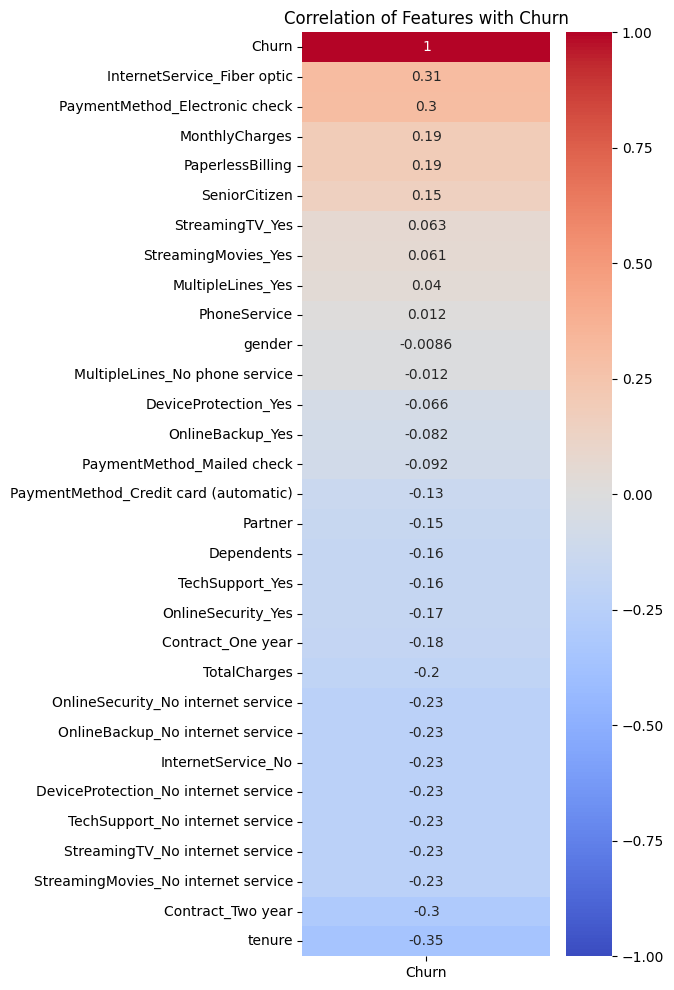

In [25]:
# Compute correlation matrix only for numeric columns
corr_matrix = df.corr(numeric_only=True)


# Focus on correlation with Churn
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn',ascending=False)

plt.figure(figsize=(4,12))
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with Churn')

plt.savefig("../images/churn_correlation.png", dpi=150, bbox_inches='tight')

plt.show()



##### Negative (lower value → less likely to churn):

  - tenure (-0.35) → Customers who stay longer are less likely to churn.
  - Contract_Two year (-0.30) → Customers on long-term contracts churn much less.
  - Contract_One year (-0.18) → Same trend but weaker than two-year contracts.

##### Positive (higher value → more likely to churn):

  - InternetService_Fiber optic (+0.31) → Fiber optic users churn more in this dataset.
  - PaymentMethod_Electronic check (+0.30) → Customers paying electronically via check churn more.

#### Look for multicolinearity (VIF)

In [26]:
df['No_internet_service'] = (
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['TechSupport_No internet service'] |
    df['StreamingTV_No internet service'] |
    df['StreamingMovies_No internet service']
    
).astype(int)


#drop the original reduntant dummies
drop_cols = [col for col in df.columns if "No internet service" in col]
df = df.drop(columns=drop_cols)

# Handle PhoneService redundancy
if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns=['MultipleLines_No phone service'])

In [27]:
df.shape

(7043, 26)

In [28]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,No_internet_service,No_phone_service
0,0,0,1,0,1,0,1,29.85,29.85,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0,1
4,0,0,0,0,2,1,1,70.70,151.65,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [29]:
df['No_phone_service'].unique()

array([1, 0])

In [30]:
df.shape

(7043, 26)

In [31]:
#Prepare X
X = df.drop(columns=['Churn'])
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [32]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,No_internet_service,No_phone_service
0,0,0,1,0,1,0,1,29.85,29.85,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0
2,1,0,0,0,2,1,1,53.85,108.15,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0,1
4,0,0,0,0,2,1,1,70.70,151.65,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [33]:
#Run VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# Remove rows with missing or infinite values
X = X.replace([np.inf,-np.inf],np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data)

c:\Users\sgfar\anaconda3\envs\torch311\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                  feature          VIF
23                    No_internet_service          inf
11                     InternetService_No          inf
5                            PhoneService  1773.528816
7                          MonthlyCharges   866.089640
10            InternetService_Fiber optic   148.500814
24                       No_phone_service    60.842267
17                    StreamingMovies_Yes    24.156394
16                        StreamingTV_Yes    24.080019
8                            TotalCharges    10.811490
4                                  tenure     7.584453
9                       MultipleLines_Yes     7.289761
14                   DeviceProtection_Yes     6.924754
13                       OnlineBackup_Yes     6.796678
15                        TechSupport_Yes     6.476508
12                     OnlineSecurity_Yes     6.338349
19                      Contract_Two year     2.652328
21         PaymentMethod_Electronic check     1.976032
22        

- Clearly we can see there's multicolinearity between features
- So either we need to drop some features or use regularization techniques like Lasso or Ridge regression to handle this
- Or use tree based models which are less sensitive to multicollinearity
- In decision trees, splits are based on feature importance for reducing impurity — redundant features just compete, but won’t cause unstable - predictions.

### Machine Learning

- Target Feature Analysis over imbalance rate

$$\text{Imbalance Ratio} = \frac{\text{Mayority Class}}{\text{Minority Class}}$$

an 1.5 ratio  is considered as desbalanced 

In [34]:
churn_count = df['Churn'].value_counts()
print(f"Abosolute Value: {churn_count}")

churn_proportion = df['Churn'].value_counts(normalize=True)
print(f"Proportion Value: {churn_proportion}")

imbalance_ratio = churn_count.max() / churn_count.min()

print(f"Imbalance Ratio: {imbalance_ratio}")

if imbalance_ratio > 3:
    print("   → Severe Desbalance: Consider use SMOTE or class weights")
elif imbalance_ratio > 1.5:
    print("   → Moderate Desbalance: Class weights probably insufficient")
else:
    print("   → Slight Desbalance: Doesn't require spceial treatment")


Abosolute Value: Churn
0    5174
1    1869
Name: count, dtype: int64
Proportion Value: Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64
Imbalance Ratio: 2.7683253076511503
   → Moderate Desbalance: Class weights probably insufficient


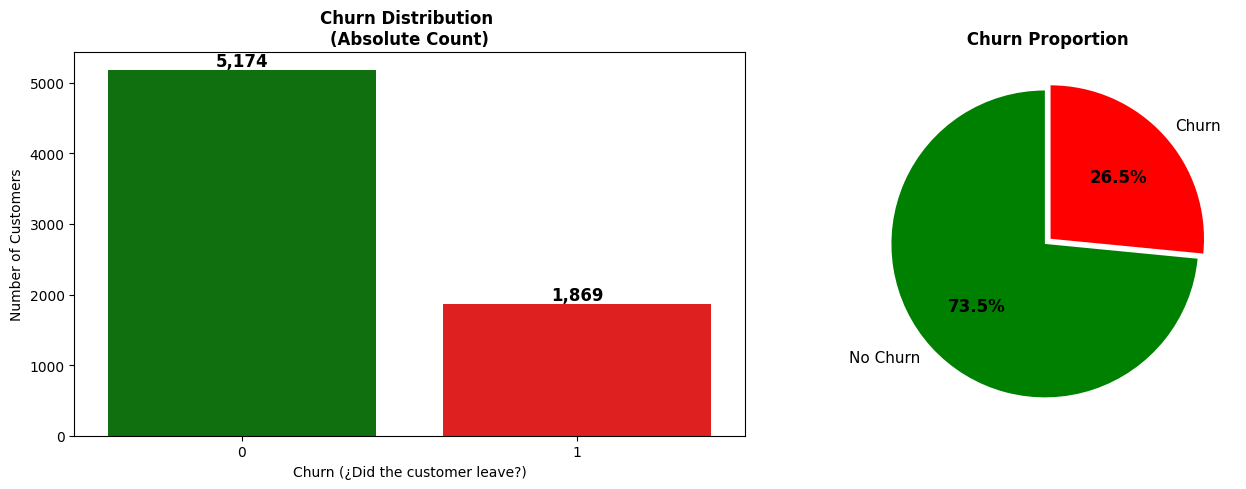

In [35]:
fig,axs = plt.subplots(1,2,figsize=(14,5))

colors = {0: 'green', 1: 'red'}  # Green = No Churn, Red = Churn

ax1 = axs[0]

sns.countplot(df,x='Churn',hue='Churn',palette=colors,ax=ax1,legend=False)

ax1.set_title('Churn Distribution \n(Absolute Count)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Churn (¿Did the customer leave?)', fontsize=10)
ax1.set_ylabel('Number of Customers', fontsize=10)

for patch in ax1.patches:
    height = patch.get_height()
    ax1.annotate(
        f'{int(height):,}', 
        xy=(patch.get_x() + patch.get_width() / 2, height), 
        ha='center', va='bottom',  
        fontsize=12, fontweight='bold'
    )

ax2 = axs[1]

# Datos para el pie
sizes = df['Churn'].value_counts().values
labels = ['No Churn', 'Churn']
explode = (0, 0.05)  

wedges, texts, autotexts = ax2.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    colors=[colors[0], colors[1]],
    textprops={'fontsize': 11}
)


for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

ax2.set_title(' Churn Proportion', fontsize=12, fontweight='bold')

plt.tight_layout()


plt.savefig("../images/churn_distribution.png",dpi=70, bbox_inches='tight')

plt.show()

In churn prediction, recall (and metrics derived from it, like F1) is usually the most important — here’s why:

1️⃣ Business context Churn prediction is asymmetric in cost:

- False Negative (FN): You predict a customer will not churn, but they actually leave → you miss the chance to intervene and keep them.

- False Positive (FP): You predict a customer will churn, but they stay → you might spend some retention resources unnecessarily.

- Missing churners (FN) usually costs more than wrongly targeting a loyal customer.

Typical priority

- If retention campaigns are cheap → prioritize recall (catch every possible churner).
- If retention campaigns are expensive → balance precision and recall using F1 score or a precision-recall trade-off.
- If business wants a ranking of churn risk → use ROC-AUC or PR-AUC to evaluate the model.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report
import time

#prepare data
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

THRESHOLD = 0.3  # lower than 0.5 to boost recall (see next to choose the right value)

### Random Forest Classifier

In [37]:
for est in range(100, 351, 50):
    rf = RandomForestClassifier(
        n_estimators=est,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    )

    rf.fit(X_train, y_train)

    proba = rf.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)

    print(f"\nRandomForest with n_estimators={est}")
    print(classification_report(y_test, y_pred, digits=3))


RandomForest with n_estimators=100
              precision    recall  f1-score   support

           0      0.893     0.758     0.820      1035
           1      0.528     0.749     0.619       374

    accuracy                          0.756      1409
   macro avg      0.711     0.754     0.720      1409
weighted avg      0.796     0.756     0.767      1409


RandomForest with n_estimators=150
              precision    recall  f1-score   support

           0      0.888     0.765     0.822      1035
           1      0.530     0.733     0.615       374

    accuracy                          0.757      1409
   macro avg      0.709     0.749     0.719      1409
weighted avg      0.793     0.757     0.767      1409


RandomForest with n_estimators=200
              precision    recall  f1-score   support

           0      0.890     0.765     0.823      1035
           1      0.532     0.738     0.618       374

    accuracy                          0.758      1409
   macro avg      0.

In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = rf.predict_proba(X_test)[:,1]

print("Threshold tuning for RandomForest")
print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test,preds,pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.503   0.786   0.613   
0.3     0.530   0.719   0.610   
0.35    0.541   0.663   0.596   
0.4     0.576   0.620   0.597   
0.45    0.607   0.553   0.579   
0.5     0.626   0.492   0.551   


#### LightGBM classifier

In [39]:
from lightgbm import LGBMClassifier
import time

lgbm = LGBMClassifier(n_estimators=500,learning_rate=0.05,class_weight='balanced',random_state=42,n_jobs=-1)

#trining timer
start_train = time.time()
lgbm.fit(X_train,y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f} seconds")

#prediction timwer
start_pred = time.time()
proba = lgbm.predict_proba(X_test)[:,1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred

print(f"Prediction time: {pred_time:.4f} seconds")

print(classification_report(y_test, y_pred, digits=3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001122 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training time: 0.97 seconds
Prediction time: 0.0062 seconds
              precision    recall  f1-score   support

           0      0.914     0.702     0.795      1035
           1      0.498     0.818     0.619       374

    accuracy                          0.733      1409
   macro avg      0.706     0.760     0.707      1409
weighted avg      0.804     0.733   

→ You’re now catching 82% of actual churners with LightGBM (improvement)

The cost is a small drop in precision — meaning more loyal customers will be flagged as churn risks — but if retention offers are low-cost, this is fine.

In [40]:
proba = lgbm.predict_proba(X_test)[:, 1]

print("Threshold tuning for LightGBM")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for LightGBM
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.479   0.842   0.610   
0.3     0.498   0.818   0.619   
0.35    0.507   0.786   0.616   
0.4     0.524   0.757   0.619   
0.45    0.537   0.741   0.622   
0.5     0.552   0.701   0.617   


#### XGBoost Classifier

In [41]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(n_estimators=500,learning_rate=0.05,max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss')

#trainig  time
start_train = time.time()
xgb.fit(X_train,y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f} seconds")

#prediction time
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:,1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.4f} seconds")

print(classification_report(y_test, y_pred, digits=3))

Training time: 0.73 seconds
Prediction time: 0.0060 seconds
              precision    recall  f1-score   support

           0      0.909     0.677     0.776      1035
           1      0.476     0.813     0.601       374

    accuracy                          0.713      1409
   macro avg      0.693     0.745     0.689      1409
weighted avg      0.794     0.713     0.730      1409



In [42]:
proba = xgb.predict_proba(X_test)[:, 1]

print("Threshold tuning for XGBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.466   0.840   0.599   
0.3     0.476   0.813   0.601   
0.35    0.497   0.786   0.609   
0.4     0.517   0.767   0.618   
0.45    0.534   0.733   0.618   
0.5     0.547   0.679   0.606   


#### ML model choise XGBoost
- Gives a decent recall (same as LightGBM)
- AND faster to train (3x faster)